In [1]:
from rdkit.Chem import Draw
from rdkit import Chem
from collections import Counter
import pandas as pd
import numpy as np
import pickle
import os

In [3]:
# Load smiles
root = "."
df = pd.read_csv(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL.tsv"), sep='\t')
df['index'] = df.index
id_to_index = dict(zip(df['id'], df['index']))
index_to_id = dict(zip(df['index'], df['id']))

# From synthon ID to SMILES
synthons = {i: j for i, j in zip(df['id'], df['smiles'])}

# Dictionary with counts of each synthon
syns_counter = dict(Counter([j for i in synthons for j in i.split("____")[1:]]))
print(f"Number of unique 'synthons': {len(syns_counter)}")

Number of unique 'synthons': 1299755


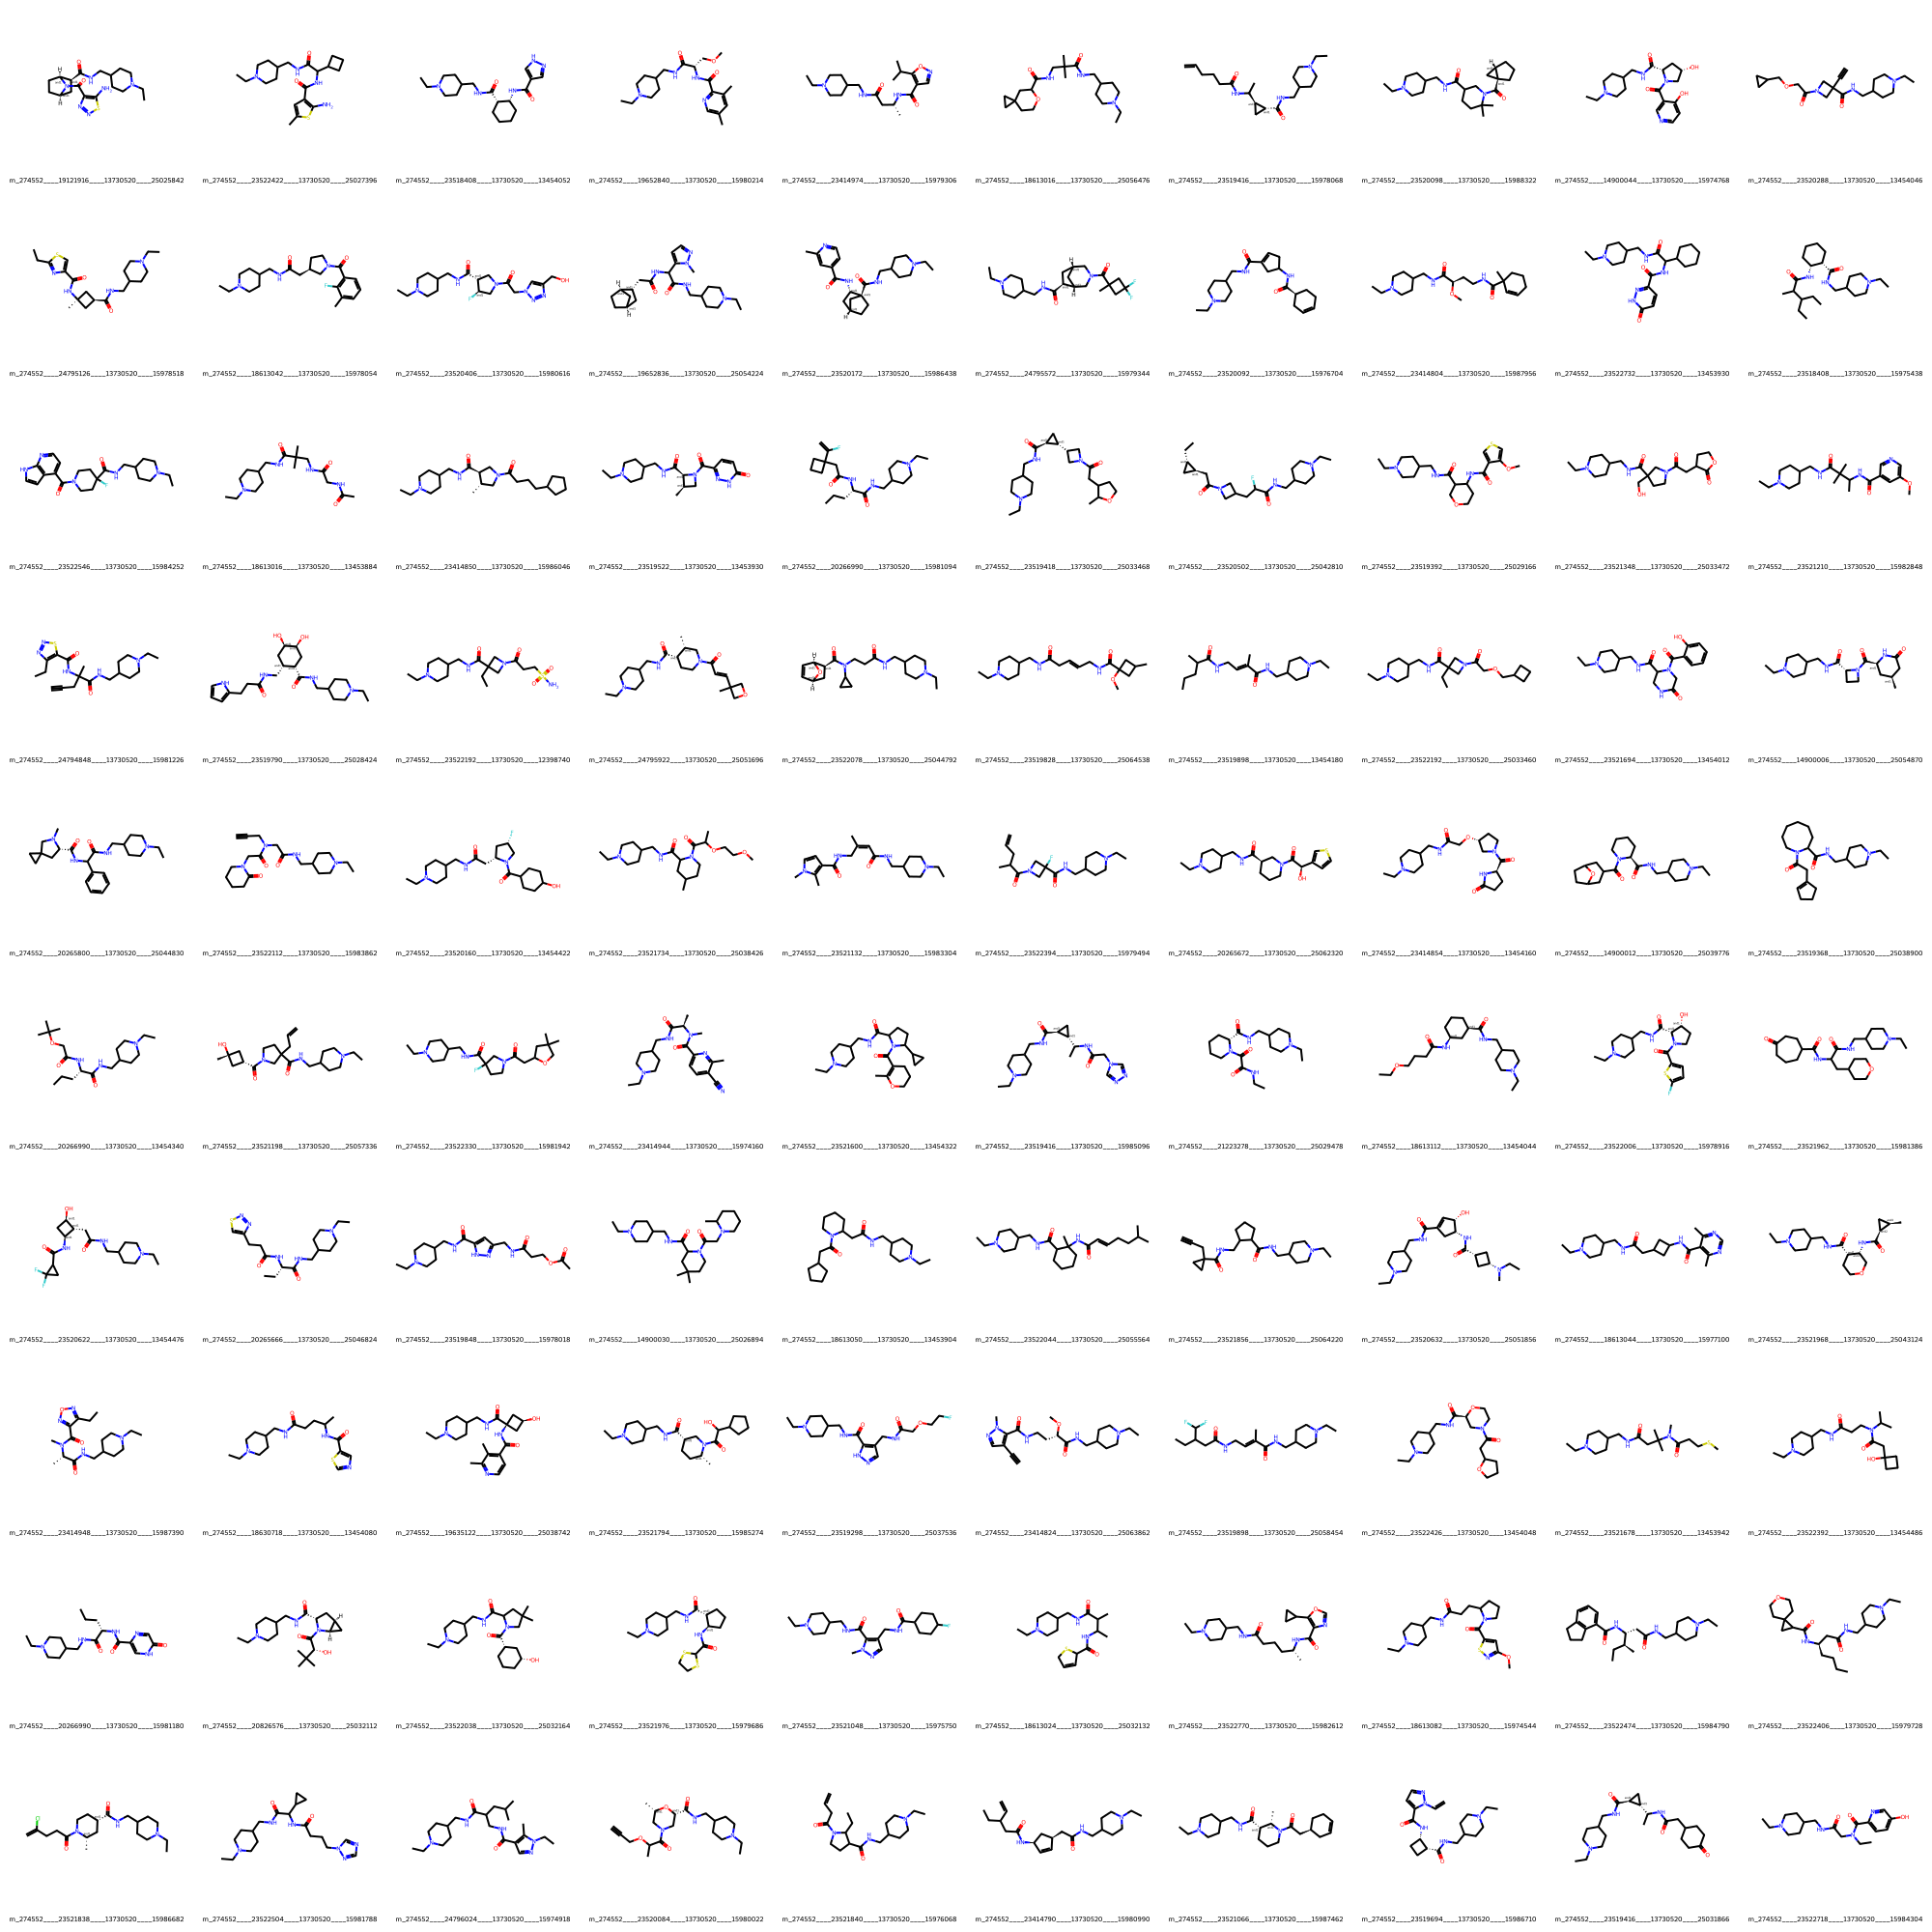

In [4]:
N = 100
s = "13730520"
# Select molecules to display
DISPLAY = [i for i in synthons if s in i.split("____")][:N]
Draw.MolsToGridImage([Chem.MolFromSmiles(synthons[i]) for i in DISPLAY], legends=DISPLAY, molsPerRow=10, maxMols=N)

In [5]:
### LOADING SUCCESS MOLECULES (IN CONFORMATION GENERATION) ###
PATH_TO_INFERRED_PROBS = os.path.join(root, "..", "processed", "unidock_docking", "inference_probs")
success_mols = np.array(pickle.load(open(os.path.join(PATH_TO_INFERRED_PROBS, "success_mols.pkl"), "rb")))

### Load pocket detection data ###
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [6]:
for file, pocket_n in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number']):

    # Pocket label
    pocket = file.replace(".pdb", "") + f"_pocket_{pocket_n}"
    
    # Load inference probabilities
    probs = np.load(os.path.join(PATH_TO_INFERRED_PROBS, f"{pocket}_bin_01.npz"))['arr_0']
    inds_probs = np.argsort(probs)[::-1]

    # Sort molecules by inferred probability
    sorted_molecules = success_mols[inds_probs]

    # From sorted molecules, get their indices in the full dataset
    sorted_indices = np.array([id_to_index[mol_id] for mol_id in sorted_molecules])

    break

In [11]:
# Counting synthons in the sorted molecules
syns_counter_tmp = {i: 0 for i in syns_counter}

# Maximum number of allowed compounds per synthon
MAX_SYN = 5
MAX_MOLS = 100000

# Molecules considered after chemical redundancy filtering
molecules_considered = []

In [12]:
for mol in sorted_molecules:

    for syn in mol.split("____")[1:]:

        if syns_counter_tmp[syn] < MAX_SYN:
            syns_counter_tmp[syn] += 1
            molecules_considered.append(mol)
        else:
            continue

        if len(molecules_considered) >= MAX_MOLS:
            break


    break